# Projet Commodities — Stratégies sur l'indice S&P GSCI ER

**Auteurs :** *Yassine Mannai, Issam Fradi, Yves-Marie Saliou & Antonin Bezard*  
**Master :** *MSc 272 - Parcours Quant*  
**Année universitaire :** *2025-2026*

---

In [ ]:
# ――― Installation des packages nécessaires ――――――――――――――――――――――――――――――――――
import subprocess, sys

PACKAGES = [
    'numpy',
    'pandas',
    'matplotlib',
    'openpyxl',
    'python-pptx',
    'python-docx',
]

for pkg in PACKAGES:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg])

print('Tous les packages sont installés.')

In [1]:
# ――― Imports ――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings('ignore')

In [ ]:
# ――― Paramètres (chemins via config.py à la racine du projet) ―――――――――――――――
import sys, os

# Racine du projet = dossier parent du notebook
ROOT = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from config import (
    DATA_PATH, OUTPUT_PATH, PRESENTATION_PATH,
    EXCEL_DATA as EXCEL_PATH,
    EXCEL_RESULTS as EXCEL_FINAL,
    LATEX_SLIDES, LATEX_RAPPORT,
    FIG_Q1, FIG_Q5, FIG_Q6, FIG_Q7, FIG_Q8,
    START_DATE, END_DATE, TICKERS,
)

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print(f'ROOT             : {ROOT}')
print(f'DATA_PATH        : {DATA_PATH}')
print(f'OUTPUT_PATH      : {OUTPUT_PATH}')
print(f'PRESENTATION_PATH: {PRESENTATION_PATH}')

---
## Q1 — Données historiques des 3 indices S&P GSCI

Les données sont récupérées via l'**API Bloomberg (blpapi)** sur la période 31/12/1969 – 31/12/2025.

| Indice | Ticker Bloomberg |
|---|---|
| S&P GSCI Spot | `SPGSCI Index` |
| S&P GSCI ER (Excess Return) | `SPGSCIP Index` |
| S&P GSCI TR (Total Return) | `SPGSCITR Index` |

In [3]:
# ――― Fonction Bloomberg ―――――――――――――――――――――――――――――――――――――――――――――――――――――
def bdh_bbg(tickers: dict, field: str, start: str, end: str) -> pd.DataFrame:
    """
    Récupère l'historique de cours depuis Bloomberg via blpapi.
    """
    import blpapi
    
    session_options = blpapi.SessionOptions()
    session_options.setServerHost('localhost')
    session_options.setServerPort(8194)

    session = blpapi.Session(session_options)
    if not session.start():
        raise ConnectionError('Impossible de démarrer la session Bloomberg')
    if not session.openService('//blp/refdata'):
        session.stop()
        raise ConnectionError("Impossible d'ouvrir le service //blp/refdata")

    ref_data_svc = session.getService('//blp/refdata')
    request = ref_data_svc.createRequest('HistoricalDataRequest')

    for ticker in tickers:
        request.getElement('securities').appendValue(ticker)
    request.getElement('fields').appendValue(field)
    request.set('startDate', start)
    request.set('endDate', end)
    request.set('periodicitySelection', 'DAILY')
    request.set('nonTradingDayFillOption', 'NON_TRADING_WEEKDAYS')
    request.set('nonTradingDayFillMethod', 'PREVIOUS_VALUE')

    session.sendRequest(request)

    raw = {name: {} for name in tickers.values()}

    while True:
        event = session.nextEvent(2000)
        for msg in event:
            if not msg.hasElement('securityData'):
                continue
            sec_data   = msg.getElement('securityData')
            bbg_ticker = sec_data.getElementAsString('security')
            col_name   = tickers.get(bbg_ticker)
            if col_name is None:
                continue
            if sec_data.hasElement('securityError'):
                continue
            field_data = sec_data.getElement('fieldData')
            for i in range(field_data.numValues()):
                row  = field_data.getValue(i)
                date = row.getElementAsDatetime('date')
                if row.hasElement(field):
                    raw[col_name][date] = row.getElementAsFloat(field)

        if event.eventType() == blpapi.Event.RESPONSE:
            break

    session.stop()

    df_out = pd.DataFrame(raw)
    df_out.index = pd.to_datetime(df_out.index)
    df_out.sort_index(inplace=True)
    return df_out


def save_to_excel(df_data: pd.DataFrame, path: str) -> None:
    """Exporte le DataFrame vers Excel avec mise en forme."""
    from openpyxl.styles import Font, PatternFill, Alignment
    df_exp = df_data[['GSCI_Spot', 'GSCI_ER', 'GSCI_TR']].copy()
    df_exp.index.name = 'Date'
    with pd.ExcelWriter(path, engine='openpyxl', date_format='DD/MM/YYYY') as writer:
        df_exp.to_excel(writer, sheet_name='Données GSCI')
        ws = writer.sheets['Données GSCI']
        for col_letter, width in zip(['A', 'B', 'C', 'D'], [14, 14, 14, 14]):
            ws.column_dimensions[col_letter].width = width
        header_fill = PatternFill(start_color='1F4E79', end_color='1F4E79', fill_type='solid')
        header_font = Font(bold=True, color='FFFFFF')
        for cell in ws[1]:
            cell.font      = header_font
            cell.fill      = header_fill
            cell.alignment = Alignment(horizontal='center')
        for row in ws.iter_rows(min_row=2, min_col=2, max_col=4):
            for cell in row:
                cell.number_format = '#,##0.0000'
    print(f'  Fichier Excel enregistré : {path}')

In [4]:
# ――― Chargement des données ―――――――――――――――――――――――――――――――――――――――――――――――――
if os.path.exists(EXCEL_PATH):
    print(f'Fichier Excel trouvé — chargement depuis {EXCEL_PATH}...')
    df = pd.read_excel(EXCEL_PATH, sheet_name='Données GSCI', index_col='Date', parse_dates=True)
    df = df.sort_index()
    df.columns = [c.strip() for c in df.columns]
    missing_cols = [c for c in ['GSCI_Spot', 'GSCI_ER', 'GSCI_TR'] if c not in df.columns]
    if missing_cols:
        raise ValueError(f'Colonnes manquantes dans le fichier Excel : {missing_cols}')
    print(f'  Excel chargé : {len(df)} lignes  ({df.index[0].date()} → {df.index[-1].date()})')
    DATA_SOURCE = f'Excel ({EXCEL_PATH})'
else:
    print('Pas de fichier Excel — connexion au Terminal Bloomberg...')
    df = bdh_bbg(TICKERS, field='PX_LAST', start=START_DATE, end=END_DATE)
    missing_cols = [c for c in ['GSCI_Spot', 'GSCI_ER', 'GSCI_TR']
                    if c not in df.columns or df[c].isna().all()]
    if missing_cols:
        raise ValueError(f'Colonnes vides ou manquantes après Bloomberg : {missing_cols}')
    print(f'  Bloomberg chargé : {len(df)} lignes  ({df.index[0].date()} → {df.index[-1].date()})')
    DATA_SOURCE = 'Bloomberg'
    save_to_excel(df, EXCEL_PATH)

print(f'\nSource : {DATA_SOURCE}')
print(f'Aperçu :')
df.tail()

Fichier Excel trouvé — chargement depuis c:\Users\b304juv\Desktop\Trading Commo\data\GSCI_Data.xlsx...
  Excel chargé : 14609 lignes  (1970-01-02 → 2025-12-31)

Source : Excel (c:\Users\b304juv\Desktop\Trading Commo\data\GSCI_Data.xlsx)
Aperçu :


,GSCI_Spot,GSCI_ER,GSCI_TR
Date,,,
2025-12-25,554.5012,306.7441,3956.176
2025-12-26,550.4011,304.4759,3927.706
2025-12-29,551.3090,304.9781,3935.357
2025-12-30,554.2844,306.6241,3956.988
2025-12-31,548.5183,303.4344,3916.219


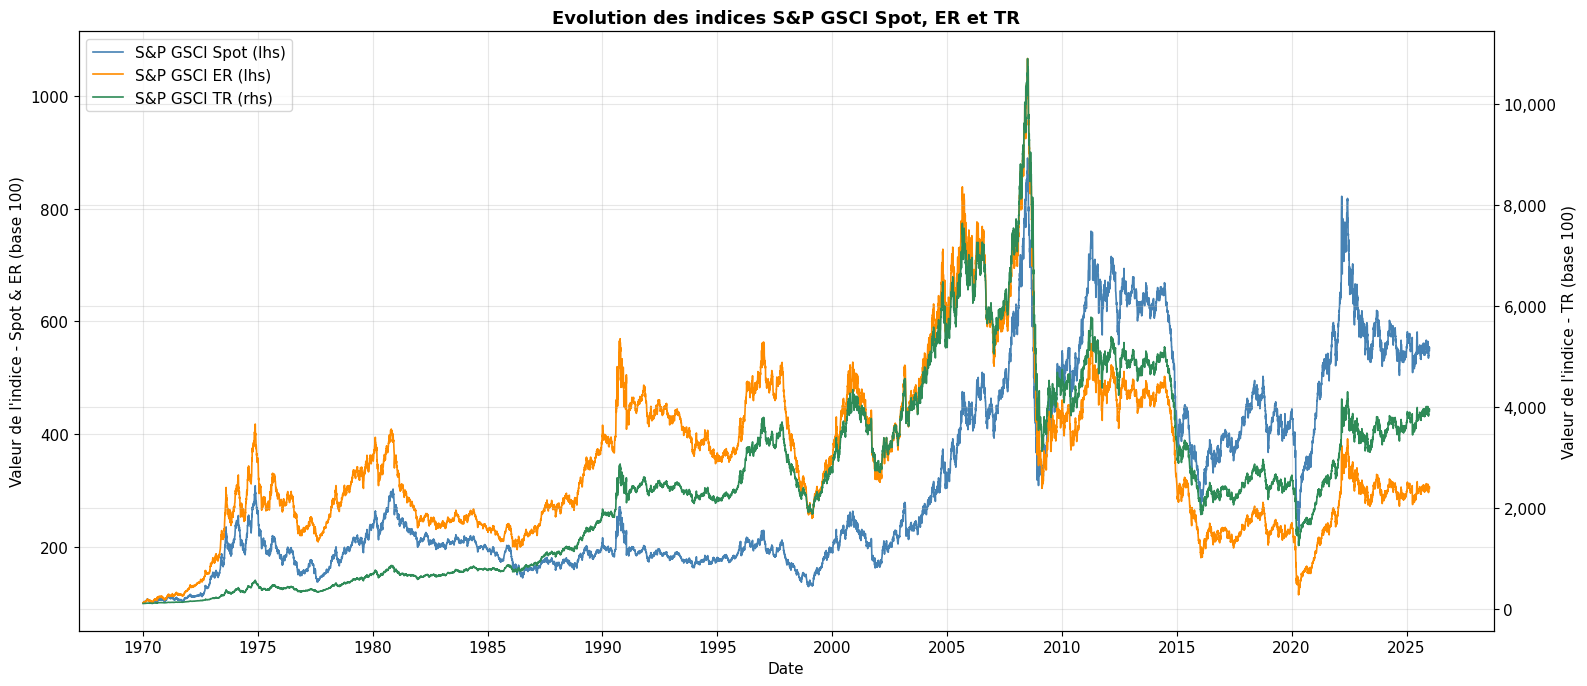

Graphique enregistré : Q1_indices.png


In [ ]:
# ――― Q1 — Graphique des 3 indices (base 100 au 31/12/1969) ――――――――――――――――――
df_idx     = df[['GSCI_Spot', 'GSCI_ER', 'GSCI_TR']].dropna()
df_rebased = df_idx / df_idx.iloc[0] * 100

fig, ax1 = plt.subplots(figsize=(16, 7))

# Axe gauche : Spot et ER
l1, = ax1.plot(df_rebased.index, df_rebased['GSCI_Spot'], label='S&P GSCI Spot', color='steelblue',  linewidth=1.2)
l2, = ax1.plot(df_rebased.index, df_rebased['GSCI_ER'],   label='S&P GSCI ER',   color='darkorange', linewidth=1.2)
ax1.set_xlabel('Date')
ax1.set_ylabel('Valeur de l\'indice - Spot & ER (base 100)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Axe droit : TR
ax2 = ax1.twinx()
l3, = ax2.plot(df_rebased.index, df_rebased['GSCI_TR'], label='S&P GSCI TR', color='seagreen', linewidth=1.2, linestyle='-')
ax2.set_ylabel('Valeur de l\'indice - TR (base 100)')
ax2.tick_params(axis='y')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Légende commune
ax1.legend(handles=[l1, l2, l3], labels=['S&P GSCI Spot (lhs)', 'S&P GSCI ER (lhs)', 'S&P GSCI TR (rhs)'],
           fontsize=11, loc='upper left')

ax1.set_title('Evolution des indices S&P GSCI Spot, ER et TR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_Q1, dpi=150)
plt.show()
print(f'Graphique enregistré : {FIG_Q1}')

---
## Q2 — Métriques de performance sur 31/12/1969 – 31/12/2025

Pour chacun des 3 indices :
- **Rendement cumulé** = $\frac{P_T - P_0}{P_0}$
- **Rendement actuariel** (CAGR) = $\left(\frac{P_T}{P_0}\right)^{\frac{1}{N}} - 1$ avec $N$ = nombre d'années
- **Volatilité annualisée** = $\sigma_{\text{journalier}} \times \sqrt{252}$
- **Ratio Rendement/Volatilité** = $\frac{\text{CAGR}}{\text{Volatilité annualisée}}$

In [6]:
# ――― Fonction de métriques de performance ―――――――――――――――――――――――――――――――――――
def performance_metrics(price_series: pd.Series, ann_factor: int = 252) -> dict:
    """Calcule les métriques de performance à partir d'une série de prix."""
    s = price_series.dropna()
    n_years = (s.index[-1] - s.index[0]).days / 365.25
    daily_returns = s.pct_change().dropna()
    
    cumul_return = (s.iloc[-1] / s.iloc[0]) - 1
    cagr = (s.iloc[-1] / s.iloc[0]) ** (1 / n_years) - 1
    vol_ann = daily_returns.std() * np.sqrt(ann_factor)
    ratio = cagr / vol_ann if vol_ann != 0 else np.nan
    
    return {
        'Rendement cumulé':           f'{cumul_return:.1%}',
        'Rendement actuariel (CAGR)': f'{cagr:.2%}',
        'Volatilité annualisée':      f'{vol_ann:.2%}',
        'Ratio Rdt / Vol':            f'{ratio:.4f}',
    }

# ――― Q2 — Tableau comparatif ―――――――――――――――――――――――――――――――――――――――――――――――
metrics = {}
for col in ['GSCI_Spot', 'GSCI_ER', 'GSCI_TR']:
    metrics[col] = performance_metrics(df[col])

df_metrics = pd.DataFrame(metrics).T
df_metrics.index = ['S&P GSCI Spot', 'S&P GSCI ER', 'S&P GSCI TR']
print('=' * 90)
print('Q2 — PERFORMANCE (31/12/1969 - 31/12/2025)')
print('=' * 90)
print(df_metrics.to_string())
print('=' * 90)

Q2 — PERFORMANCE (31/12/1969 - 31/12/2025)
              Rendement cumulé Rendement actuariel (CAGR) Volatilité annualisée Ratio Rdt / Vol
S&P GSCI Spot           448.5%                      3.09%                19.16%          0.1610
S&P GSCI ER             203.4%                      2.00%                19.12%          0.1047
S&P GSCI TR            3816.2%                      6.77%                19.12%          0.3541


---
## Q3 — Explication des différences de rendement

### Spot vs ER (Excess Return)

L'indice **Spot** reflète la variation du **prix au comptant** des matières premières (pondérées par la production mondiale).  
L'indice **ER (Excess Return)** intègre en plus la composante de **roll yield**, qui représente le coût (ou bénéfice) du renouvellement des contrats futures :

$$\text{GSCI ER} = \text{GSCI Spot} + \underbrace{\text{Roll Yield}}_{\text{coût de portage}}$$

En **backwardation** (prix spot > prix futures), le roll yield est positif.  
En **contango** (prix spot < prix futures), le roll yield est négatif.  

Sur longue période, les matières premières sont majoritairement en **contango**, ce qui explique que le GSCI ER sous-performe structurellement le GSCI Spot.

### ER vs TR (Total Return)

L'indice **TR (Total Return)** ajoute à l'ER le **rendement du collatéral** (intérêts sur les T-bills US déposés en garantie) :

$$\text{GSCI TR} = \text{GSCI ER} + \underbrace{\text{Collateral Return}}_{\approx \text{taux sans risque}}$$

Historiquement, les taux courts américains ont été en moyenne proches de **4–5 % par an**, ce qui explique la surperformance significative du TR versus l'ER sur longue période.

---
## Q4 — Méthode de calcul automatique de la Moyenne Mobile

La **moyenne mobile simple (MMS)** sur $n$ jours en date $t$ est :

$$\text{MA}_n(t) = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$

La cellule ci-dessous propose une fonction générique réplicable sur n'importe quel historique et n'importe quelle fenêtre.

In [7]:
# ――― Q4 — Fonction de calcul de moyenne mobile ――――――――――――――――――――――――――――――
def moving_average(price_series: pd.Series, window: int) -> pd.Series:
    """
    Moyenne mobile simple sur `window` jours.
    Équivalent Excel : =AVERAGE(P[n]:P[n-window+1])
    """
    return price_series.rolling(window=window, min_periods=window).mean()

# Test rapide
ma50_test = moving_average(df['GSCI_ER'], 50)
print(f'MA50 — Dernières 5 valeurs :')
print(ma50_test.tail())
print(f'\nPremière valeur non-NaN : {ma50_test.first_valid_index()}')

MA50 — Dernières 5 valeurs :
Date
2025-12-25    304.425742
2025-12-26    304.573834
2025-12-29    304.679846
2025-12-30    304.848508
2025-12-31    304.910224
Name: GSCI_ER, dtype: float64

Première valeur non-NaN : 1970-03-12 00:00:00


---
## Q5 — Calcul des 5 moyennes mobiles (25, 50, 100, 150, 200 jours)

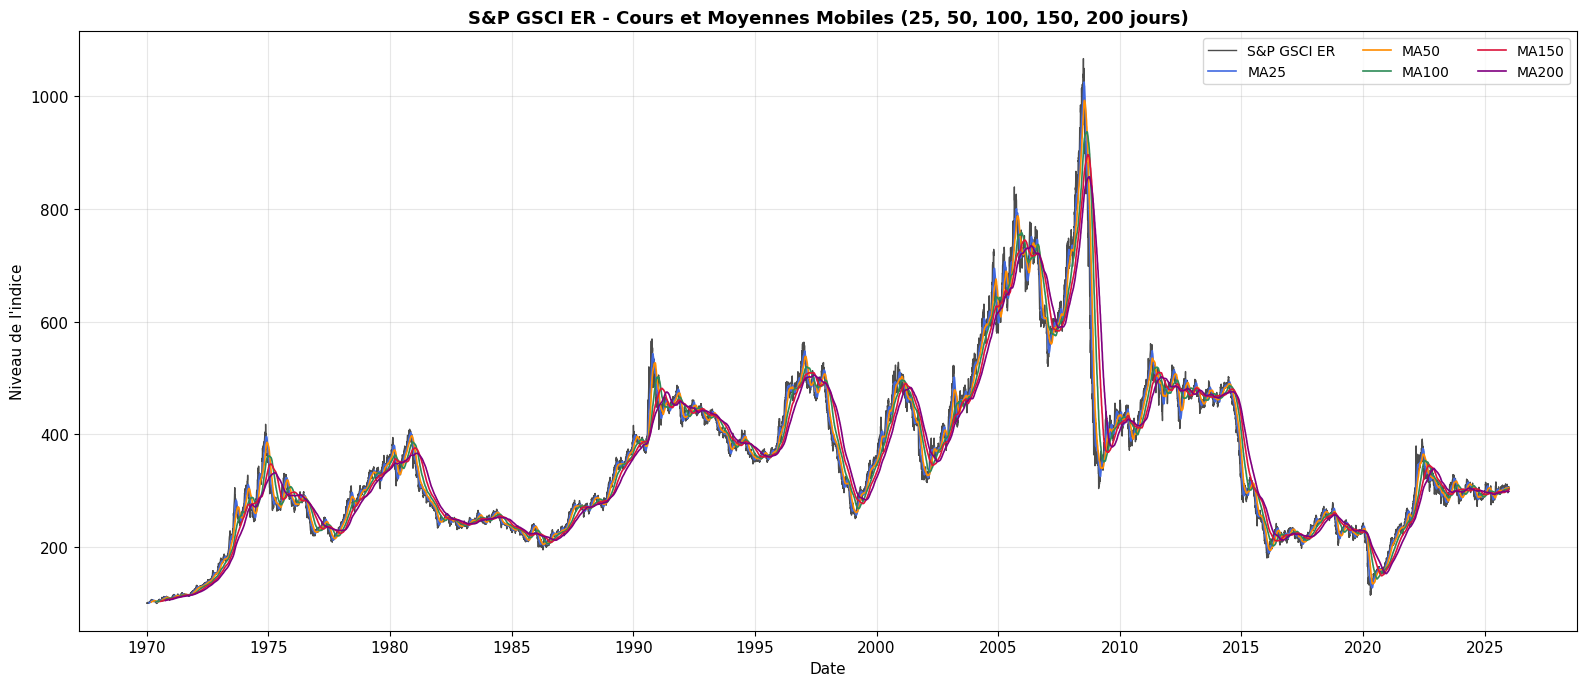

Graphique enregistré : Q5_moving_averages.png


In [ ]:
# ――― Q5 — Calcul des 5 MAs sur le GSCI ER ――――――――――――――――――――――――――――――――――――
WINDOWS = [25, 50, 100, 150, 200]

er = df['GSCI_ER'].dropna().copy()

ma_dict = {}
for w in WINDOWS:
    ma_dict[w] = moving_average(er, w)

# ―― Graphique : GSCI ER + 5 MAs ――――――――――――――――――――――――――――――――――――――――――――――
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(er.index, er, label='S&P GSCI ER', color='black', linewidth=1.0, alpha=0.7)

colors = ['royalblue', 'darkorange', 'seagreen', 'crimson', 'purple']
for w, col in zip(WINDOWS, colors):
    ax.plot(ma_dict[w].index, ma_dict[w], label=f'MA{w}', color=col, linewidth=1.2)

ax.set_title('S&P GSCI ER - Cours et Moyennes Mobiles (25, 50, 100, 150, 200 jours)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Niveau de l\'indice')
ax.legend(fontsize=10, ncol=3)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(FIG_Q5, dpi=150)
plt.show()
print(f'Graphique enregistré : {FIG_Q5}')

---
## Q6 — Backtest des 5 stratégies Moyenne Mobile

**Règle du signal :**
- **Signal achat (position = 1)** : le cours de clôture dépasse à la hausse sa moyenne mobile → $P_t > \text{MA}_n(t)$
- **Signal neutre (position = 0)** : sinon (pas de vente à découvert)

Chaque stratégie génère un **indice de valeur 100 au 31/12/1969** en appliquant les rendements journaliers uniquement lors des jours en position *achat*.

In [9]:
# ――― Q6 ― Backtest : construction des 5 indices MA ―――――――――――――――――――――――――
def backtest_ma_strategy(price: pd.Series, window: int) -> pd.Series:
    """
    Construit un indice de stratégie MA :
    - Position = 1 (long) quand price[t-1] > MA[t-1]  (signal calculé veille)
    - Position = 0 sinon
    - L'indice démarre à 100 à la première date disponible.
    """
    ma = moving_average(price, window)
    # Signal décalé d'un jour pour éviter le look-ahead bias
    signal = (price.shift(1) > ma.shift(1)).astype(int)
    
    daily_ret = price.pct_change()
    strat_ret = signal * daily_ret
    
    # On commence après avoir suffisamment d'historique pour la MA
    strat_ret_clean = strat_ret.iloc[window:]
    
    index_vals = 100.0 * (1 + strat_ret_clean).cumprod()
    # Compléter avec 100 pour les premières dates (période sans signal)
    prefix = pd.Series(100.0, index=price.index[:window])
    index_vals = pd.concat([prefix, index_vals])
    return index_vals

# Construction des indices stratégies
strat_indices = {}
for w in WINDOWS:
    strat_indices[w] = backtest_ma_strategy(er, w)
    print(f'MA{w:3d} — Indice calculé ({len(strat_indices[w])} points)')

print('\nBacktest terminé.')

MA 25 — Indice calculé (14609 points)
MA 50 — Indice calculé (14609 points)
MA100 — Indice calculé (14609 points)
MA150 — Indice calculé (14609 points)
MA200 — Indice calculé (14609 points)

Backtest terminé.


In [10]:
# ――― Q6 — Métriques de performance des 5 stratégies ――――――――――――――――――――――――――
def performance_from_index(index_series: pd.Series, ann_factor: int = 252) -> dict:
    """Métriques depuis un indice synthétique rebasé."""
    s = index_series.dropna()
    n_years = (s.index[-1] - s.index[0]).days / 365.25

    cumul = (s.iloc[-1] / s.iloc[0]) - 1
    cagr  = (s.iloc[-1] / s.iloc[0]) ** (1 / n_years) - 1

    daily_ret = s.pct_change().dropna()
    # Volatilité calculée uniquement sur les jours de position active
    vol_ann = daily_ret[daily_ret != 0].std() * np.sqrt(ann_factor)
    ratio   = cagr / vol_ann if vol_ann != 0 else np.nan

    return {
        'Rendement cumulé':           f'{cumul:.1%}',
        'Rendement actuariel (CAGR)': f'{cagr:.2%}',
        'Volatilité annualisée':      f'{vol_ann:.2%}',
        'Ratio Rdt / Vol':            f'{ratio:.4f}',
    }

# Référence : GSCI ER buy-and-hold
bh_metrics = performance_metrics(er)

rows = {'GSCI ER (Buy & Hold)': bh_metrics}
for w in WINDOWS:
    rows[f'Stratégie MA{w}'] = performance_from_index(strat_indices[w])

df_q6 = pd.DataFrame(rows).T
print('=' * 80)
print('Q6 — PERFORMANCE DES 5 STRATÉGIES MA vs GSCI ER BUY & HOLD')
print('=' * 80)
print(df_q6.to_string())
print('=' * 80)

Q6 — PERFORMANCE DES 5 STRATÉGIES MA vs GSCI ER BUY & HOLD
                     Rendement cumulé Rendement actuariel (CAGR) Volatilité annualisée Ratio Rdt / Vol
GSCI ER (Buy & Hold)           203.4%                      2.00%                19.12%          0.1047
Stratégie MA25                1561.2%                      5.15%                18.25%          0.2821
Stratégie MA50                 785.3%                      3.97%                18.13%          0.2190
Stratégie MA100               1622.9%                      5.22%                18.26%          0.2856
Stratégie MA150               1235.9%                      4.74%                18.72%          0.2532
Stratégie MA200                725.3%                      3.84%                18.84%          0.2039


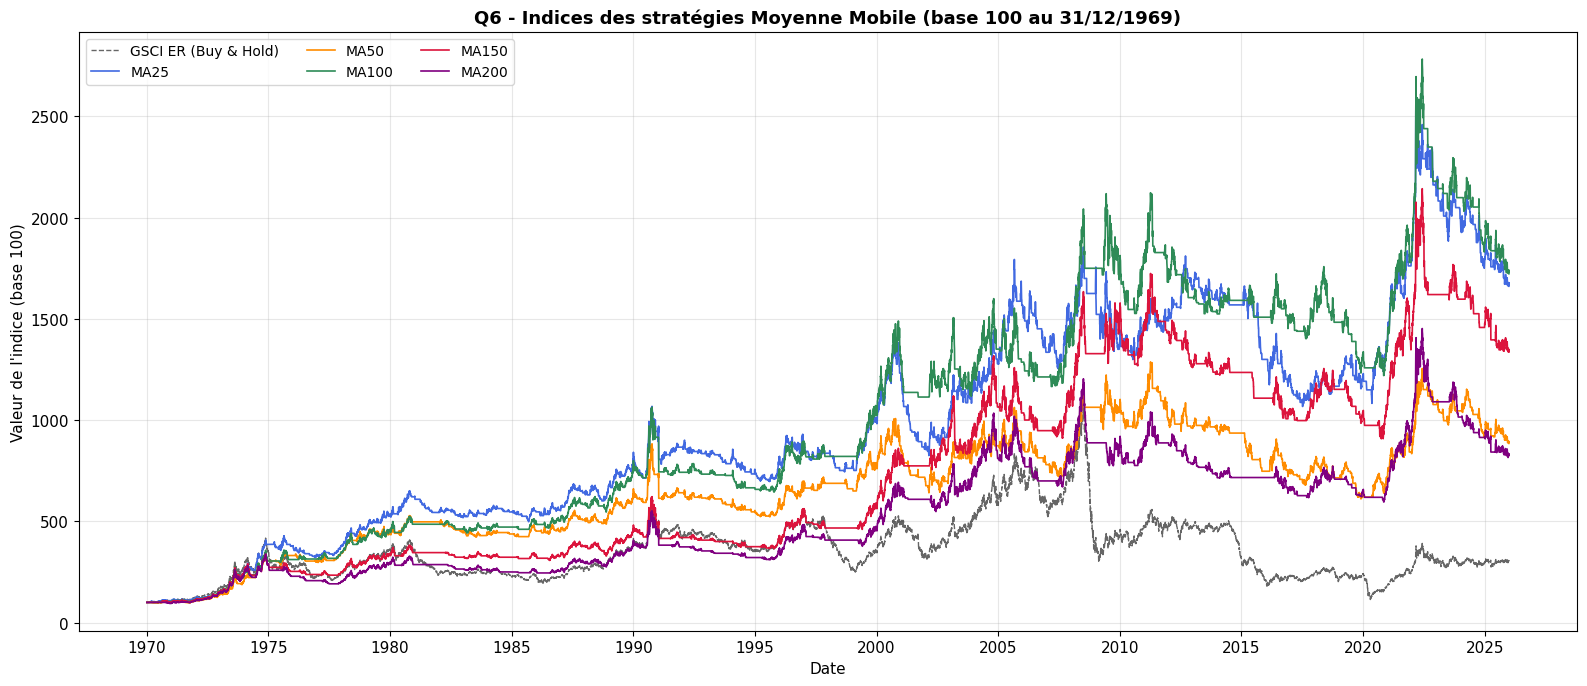

Graphique enregistré : Q6_strategies.png


In [ ]:
# ――― Q6 — Graphique des 5 indices stratégie ――――――――――――――――――――――――――――――――――
fig, ax = plt.subplots(figsize=(16, 7))

# GSCI ER rebased à 100
er_rebased = er / er.iloc[0] * 100
ax.plot(er_rebased.index, er_rebased, label='GSCI ER (Buy & Hold)', color='black', linewidth=1.0, alpha=0.6, linestyle='--')

for w, col in zip(WINDOWS, colors):
    ax.plot(strat_indices[w].index, strat_indices[w], label=f'MA{w}', color=col, linewidth=1.2)

ax.set_title('Q6 - Indices des stratégies Moyenne Mobile (base 100 au 31/12/1969)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Valeur de l\'indice (base 100)')
ax.legend(fontsize=10, ncol=3)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(FIG_Q6, dpi=150)
plt.show()
print(f'Graphique enregistré : {FIG_Q6}')

---
## Q7 — Portefeuille équi-pondéré des 5 stratégies MA

Le portefeuille combine les 5 stratégies avec un poids égal de $\frac{1}{5}$ chacune.  
À chaque instant $t$, le rendement du portefeuille vaut :

$$r_{\text{portef}}(t) = \frac{1}{5} \sum_{k \in \{25,50,100,150,200\}} r_k(t)$$

Q7 — PERFORMANCE DU PORTEFEUILLE ÉQUI-PONDÉRÉ (5 stratégies MA)
  Rendement cumulé                    1231.7%
  Rendement actuariel (CAGR)          4.73%
  Volatilité annualisée               14.60%
  Ratio Rdt / Vol                     0.3243


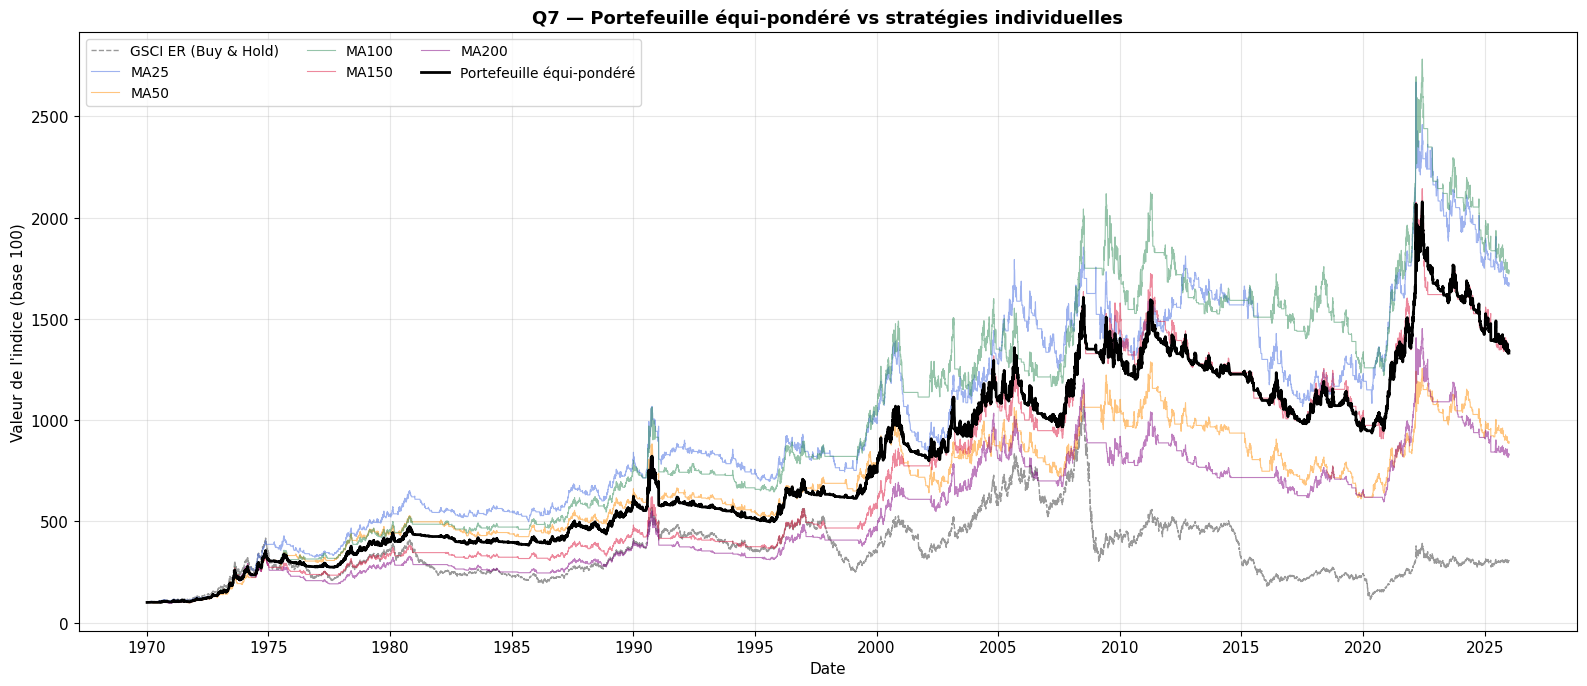

Graphique enregistré : Q7_portfolio.png


In [ ]:
# ――― Q7 — Portefeuille équi-pondéré des 5 stratégies ―――――――――――――――――――――――――
strat_returns = pd.DataFrame({f'MA{w}': strat_indices[w].pct_change() for w in WINDOWS}).dropna(how='all')

# Rendement quotidien du portefeuille = moyenne simple des 5 stratégies
port_ret = strat_returns.mean(axis=1)

# Construire l'indice du portefeuille (base 100)
port_index = 100.0 * (1 + port_ret.fillna(0)).cumprod()

# ―― Métriques ――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
port_perf = performance_from_index(port_index)

print('=' * 70)
print('Q7 — PERFORMANCE DU PORTEFEUILLE ÉQUI-PONDÉRÉ (5 stratégies MA)')
print('=' * 70)
for k, v in port_perf.items():
    print(f'  {k:<35} {v}')
print('=' * 70)

# ―― Graphique ――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(er_rebased.index, er_rebased, label='GSCI ER (Buy & Hold)', color='gray', linewidth=1.0, linestyle='--', alpha=0.8)
for w, col in zip(WINDOWS, colors):
    ax.plot(strat_indices[w].index, strat_indices[w], label=f'MA{w}', color=col, linewidth=0.8, alpha=0.5)
ax.plot(port_index.index, port_index, label='Portefeuille équi-pondéré', color='black', linewidth=2.0)

ax.set_title('Q7 — Portefeuille équi-pondéré vs stratégies individuelles', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Valeur de l\'indice (base 100)')
ax.legend(fontsize=10, ncol=3)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(FIG_Q7, dpi=150)
plt.show()
print(f'Graphique enregistré : {FIG_Q7}')

---
## Q8 — Stratégie améliorée : Vote Majoritaire des MAs + Filtre de Volatilité

### Logique de la stratégie

La stratégie combine **deux mécanismes** pour améliorer le ratio rendement/volatilité :

1. **Vote majoritaire des 5 MAs** : On calcule les 5 signaux MA individuels (25, 50, 100, 150, 200). La position est longue uniquement si **au moins 3 signaux sur 5 sont positifs** (vote majoritaire). Cela filtre les faux signaux et ne conserve que les tendances confirmées par plusieurs horizons.

2. **Filtre de volatilité (réduction d'exposition en régime de haute volatilité)** : On calcule la volatilité réalisée sur 20 jours. Si celle-ci dépasse 1.5× sa médiane historique glissante (252 jours), on passe en position neutre. Cela protège le portefeuille lors des crises et des krachs.

$$\text{Signal} = \begin{cases} 1 & \text{si } \sum_{k} \mathbb{1}_{P > MA_k} \geq 3 \;\text{ ET }\; \sigma_{20} < 1.5 \times \text{médiane}(\sigma_{20}) \\ 0 & \text{sinon} \end{cases}$$

In [13]:
# ――― Q8 — Stratégie Vote Majoritaire + Filtre Volatilité ―――――――――――――――――――――
def backtest_majority_vote_strategy(
    price: pd.Series,
    windows: list = [25, 50, 100, 150, 200],
    min_signals: int = 3,
    vol_window: int = 20,
    vol_lookback: int = 252,
    vol_multiplier: float = 1.5,
) -> tuple:
    """
    Stratégie combinée :
    - Vote majoritaire : position longue si au moins `min_signals` MAs sont franchies
    - Filtre de volatilité : position neutre si vol réalisée > vol_multiplier × médiane glissante
    """
    # Calcul des signaux MA individuels (décalés d'un jour)
    signals = pd.DataFrame(index=price.index)
    for w in windows:
        ma = price.rolling(window=w, min_periods=w).mean()
        signals[f'MA{w}'] = (price.shift(1) > ma.shift(1)).astype(int)
    
    # Vote majoritaire : nombre de signaux positifs
    vote_count = signals.sum(axis=1)
    signal_majority = (vote_count >= min_signals).astype(int)
    
    # Filtre de volatilité
    daily_ret = price.pct_change()
    vol_realized = daily_ret.rolling(window=vol_window).std() * np.sqrt(252)
    vol_median = vol_realized.rolling(window=vol_lookback, min_periods=50).median()
    vol_filter = (vol_realized.shift(1) < vol_multiplier * vol_median.shift(1)).astype(int)
    
    # Signal final = majorité ET volatilité OK
    signal = signal_majority * vol_filter
    
    strat_ret = signal * daily_ret
    index_vals = 100.0 * (1 + strat_ret.fillna(0)).cumprod()
    
    return index_vals, signal, vote_count, vol_realized


# ―― Calcul de la stratégie ―――――――――――――――――――――――――――――――――――――――――――――――――――
enhanced_idx, signal_series, vote_series, vol_series = backtest_majority_vote_strategy(er)

# ―― Métriques comparatives ――――――――――――――――――――――――――――――――――――――――――――――――――
enhanced_perf = performance_from_index(enhanced_idx)

print('=' * 80)
print('Q8 — COMPARAISON : Vote Majoritaire + Vol Filter vs Q7 vs Buy & Hold')
print('=' * 80)
rows_q8 = {
    'GSCI ER (Buy & Hold)':           performance_metrics(er),
    'Portefeuille équi-pondéré (Q7)': port_perf,
    'Vote Majoritaire + Vol Filter':  enhanced_perf,
}
df_q8 = pd.DataFrame(rows_q8).T
print(df_q8.to_string())
print('=' * 80)

# Statistiques de la stratégie
pct_invested = signal_series.mean() * 100
print(f'\n  Temps investi : {pct_invested:.1f}%')
print(f'  Nombre de trades : {(signal_series.diff().abs() > 0).sum()}')

Q8 — COMPARAISON : Vote Majoritaire + Vol Filter vs Q7 vs Buy & Hold
                               Rendement cumulé Rendement actuariel (CAGR) Volatilité annualisée Ratio Rdt / Vol
GSCI ER (Buy & Hold)                     203.4%                      2.00%                19.12%          0.1047
Portefeuille équi-pondéré (Q7)          1231.7%                      4.73%                14.60%          0.3243
Vote Majoritaire + Vol Filter           2830.0%                      6.22%                17.02%          0.3653

  Temps investi : 50.8%
  Nombre de trades : 727


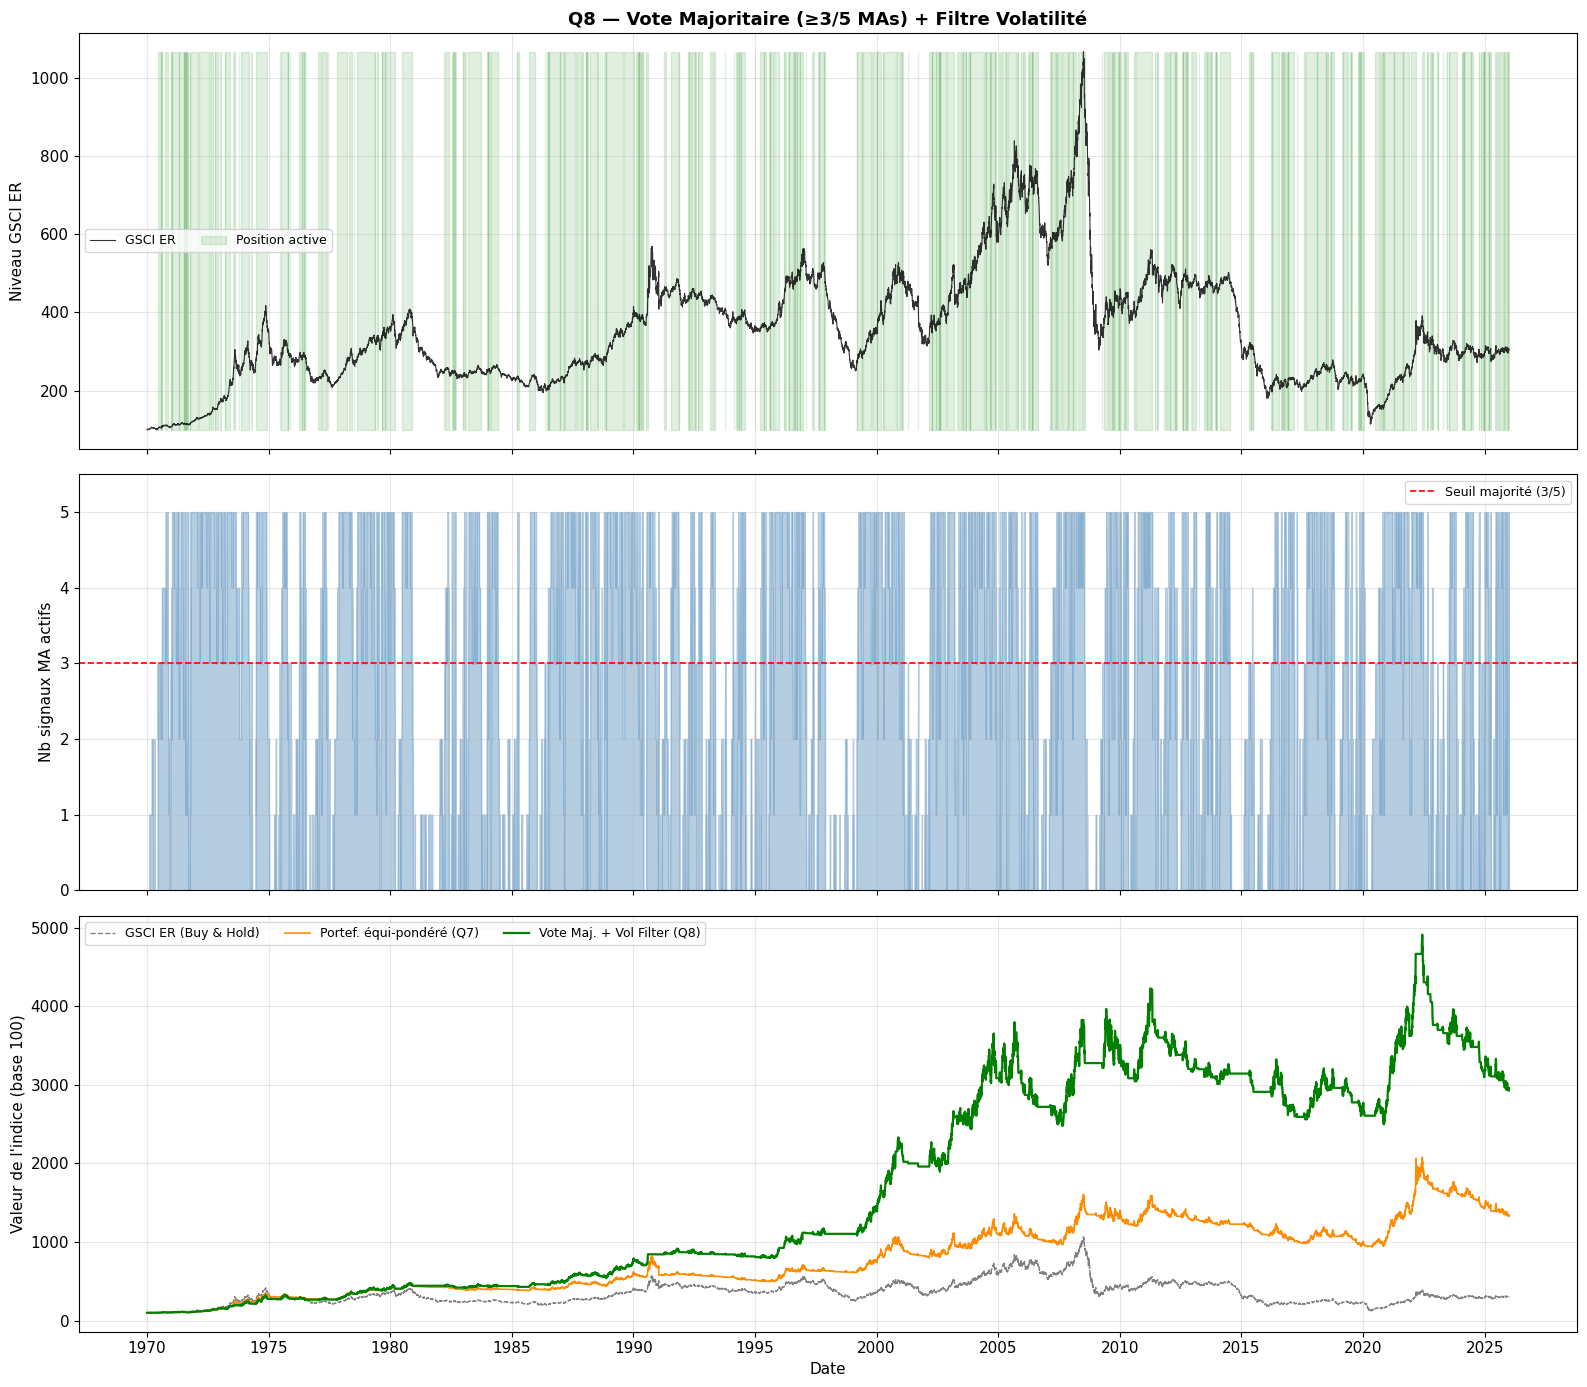

Graphique enregistré : Q8_enhanced_strategy.png


In [ ]:
# ――― Q8 — Graphique stratégie améliorée ――――――――――――――――――――――――――――――――――――――
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

# Panel 1 : Cours + zones de position
ax0 = axes[0]
ax0.plot(er.index, er, color='black', linewidth=0.8, label='GSCI ER', alpha=0.8)
ax0.fill_between(signal_series.index, er.min(), er.max(),
                 where=signal_series == 1, alpha=0.12, color='green', label='Position active')
ax0.set_ylabel('Niveau GSCI ER')
ax0.set_title('Q8 — Vote Majoritaire (≥3/5 MAs) + Filtre Volatilité', fontsize=13, fontweight='bold')
ax0.legend(fontsize=9, ncol=2)

# Panel 2 : Nombre de signaux MA actifs
ax1 = axes[1]
ax1.fill_between(vote_series.index, 0, vote_series, alpha=0.4, color='steelblue')
ax1.axhline(3, color='red', linestyle='--', linewidth=1.2, label='Seuil majorité (3/5)')
ax1.set_ylim(0, 5.5)
ax1.set_ylabel('Nb signaux MA actifs')
ax1.legend(fontsize=9)

# Panel 3 : Performance cumulative
ax2 = axes[2]
ax2.plot(er_rebased.index, er_rebased,    label='GSCI ER (Buy & Hold)', color='gray', linestyle='--', linewidth=1.0)
ax2.plot(port_index.index, port_index,     label='Portef. équi-pondéré (Q7)', color='darkorange', linewidth=1.2)
ax2.plot(enhanced_idx.index, enhanced_idx, label='Vote Maj. + Vol Filter (Q8)', color='green', linewidth=1.6)
ax2.set_ylabel('Valeur de l\'indice (base 100)')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9, ncol=3)
ax2.xaxis.set_major_locator(mdates.YearLocator(5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(FIG_Q8, dpi=150)
plt.show()
print(f'Graphique enregistré : {FIG_Q8}')

---
## Résumé synthétique

In [15]:
# ――― Tableau récapitulatif final ――――――――――――――――――――――――――――――――――――――――――――――
all_rows = {
    'S&P GSCI Spot':                 performance_metrics(df['GSCI_Spot']),
    'S&P GSCI ER (Buy & Hold)':      performance_metrics(er),
    'S&P GSCI TR':                   performance_metrics(df['GSCI_TR']),
}
for w in WINDOWS:
    all_rows[f'Stratégie MA{w}'] = performance_from_index(strat_indices[w])

all_rows['Portefeuille équi-pondéré (Q7)'] = port_perf
all_rows['Vote Majoritaire + Vol Filter (Q8)'] = enhanced_perf

df_final = pd.DataFrame(all_rows).T
print('=' * 80)
print('  TABLEAU RÉCAPITULATIF COMPLET — Projet Commodities 2026')
print('=' * 80)
print(df_final.to_string())
print('=' * 80)

  TABLEAU RÉCAPITULATIF COMPLET — Projet Commodities 2026
                                   Rendement cumulé Rendement actuariel (CAGR) Volatilité annualisée Ratio Rdt / Vol
S&P GSCI Spot                                448.5%                      3.09%                19.16%          0.1610
S&P GSCI ER (Buy & Hold)                     203.4%                      2.00%                19.12%          0.1047
S&P GSCI TR                                 3816.2%                      6.77%                19.12%          0.3541
Stratégie MA25                              1561.2%                      5.15%                18.25%          0.2821
Stratégie MA50                               785.3%                      3.97%                18.13%          0.2190
Stratégie MA100                             1622.9%                      5.22%                18.26%          0.2856
Stratégie MA150                             1235.9%                      4.74%                18.72%          0.2532
Straté

---
## Notes méthodologiques

- **Données** : récupérées via l'API Bloomberg (`blpapi`) — tickers `SPGSCI Index`, `SPGSCIP Index`, `SPGSCITR Index`. Fallback depuis fichier Excel si le Terminal Bloomberg n'est pas disponible.
- **No look-ahead bias** : tous les signaux sont calculés avec un décalage d'un jour (`shift(1)`) pour reproduire la décision du soir J appliquée en J+1.
- **Coûts de transaction** : non pris en compte (comme demandé dans l'énoncé).
- **Volatilité des stratégies** : calculée uniquement sur les jours de position active (rendements ≠ 0).

---
## Exports — Excel, Slides LaTeX (Beamer) & Rapport LaTeX

In [ ]:
# ――― Export Excel complet (interface de présentation) ―――――――――――――――――――――――――
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side, numbers
from openpyxl.chart import LineChart, Reference
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.utils import get_column_letter
from copy import copy

# EXCEL_FINAL importé depuis config.py

# ―― Helpers ――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
hdr_fill = PatternFill(start_color='1F4E79', end_color='1F4E79', fill_type='solid')
hdr_font = Font(bold=True, color='FFFFFF', size=10, name='Calibri')
alt_fill = PatternFill(start_color='DEEAF1', end_color='DEEAF1', fill_type='solid')
thin_border = Border(
    left=Side('thin'), right=Side('thin'), top=Side('thin'), bottom=Side('thin'))

def style_ws(ws):
    """Style une feuille : en-tête bleu, alternance de lignes, bordures, largeur auto."""
    for cell in ws[1]:
        cell.font = hdr_font
        cell.fill = hdr_fill
        cell.alignment = Alignment(horizontal='center', vertical='center')
        cell.border = thin_border
    for i, row in enumerate(ws.iter_rows(min_row=2, max_row=ws.max_row, max_col=ws.max_column)):
        for cell in row:
            cell.alignment = Alignment(horizontal='center')
            cell.border = thin_border
            if i % 2 == 1:
                cell.fill = alt_fill
    for col in ws.columns:
        max_len = max(len(str(c.value or '')) for c in col) + 3
        ws.column_dimensions[col[0].column_letter].width = min(max_len, 28)

def write_df(writer, df, sheet_name, index=True):
    df.to_excel(writer, sheet_name=sheet_name, index=index)
    style_ws(writer.sheets[sheet_name])

# ―― Construction du fichier Excel ――――――――――――――――――――――――――――――――――――――――――――
with pd.ExcelWriter(EXCEL_FINAL, engine='openpyxl') as writer:
    
    # 1. Données brutes (Q1)
    df_export = df[['GSCI_Spot', 'GSCI_ER', 'GSCI_TR']].copy()
    df_export.index.name = 'Date'
    df_export.to_excel(writer, sheet_name='Q1_Données')
    style_ws(writer.sheets['Q1_Données'])
    
    # 2. Métriques Q2
    write_df(writer, df_metrics, 'Q2_Performance')
    
    # 3. Moyennes mobiles (Q5) — échantillon (tous les mois)
    ma_export = pd.DataFrame({'GSCI_ER': er})
    for w in WINDOWS:
        ma_export[f'MA{w}'] = ma_dict[w]
    ma_monthly = ma_export.resample('ME').last()
    ma_monthly.index.name = 'Date'
    ma_monthly.to_excel(writer, sheet_name='Q5_Moyennes_Mobiles')
    style_ws(writer.sheets['Q5_Moyennes_Mobiles'])
    
    # 4. Stratégies MA — indices (Q6) — mensuel
    strat_export = pd.DataFrame({'GSCI_ER (base 100)': er / er.iloc[0] * 100})
    for w in WINDOWS:
        strat_export[f'MA{w}'] = strat_indices[w]
    strat_monthly = strat_export.resample('ME').last()
    strat_monthly.index.name = 'Date'
    strat_monthly.to_excel(writer, sheet_name='Q6_Indices_Strategies')
    style_ws(writer.sheets['Q6_Indices_Strategies'])
    
    # 5. Performance Q6
    write_df(writer, df_q6, 'Q6_Performance')
    
    # 6. Portefeuille Q7
    q7_export = pd.DataFrame({'Portefeuille (base 100)': port_index,
                              'GSCI_ER (base 100)': er / er.iloc[0] * 100})
    q7_monthly = q7_export.resample('ME').last()
    q7_monthly.index.name = 'Date'
    q7_monthly.to_excel(writer, sheet_name='Q7_Portefeuille')
    style_ws(writer.sheets['Q7_Portefeuille'])
    
    # 7. Stratégie Q8
    q8_export = pd.DataFrame({
        'GSCI_ER (base 100)': er / er.iloc[0] * 100,
        'Vote Maj + Vol Filter': enhanced_idx,
        'Signal': signal_series,
        'Nb MAs actives': vote_series,
    })
    q8_monthly = q8_export.resample('ME').last()
    q8_monthly.index.name = 'Date'
    q8_monthly.to_excel(writer, sheet_name='Q8_Strategie')
    style_ws(writer.sheets['Q8_Strategie'])
    
    # 8. Performance Q8
    write_df(writer, df_q8, 'Q8_Performance')
    
    # 9. Récapitulatif complet
    write_df(writer, df_final, 'Récapitulatif')

print(f'Excel complet généré : {EXCEL_FINAL}')
print(f'  → Feuilles : Q1_Données, Q2_Performance, Q5_Moyennes_Mobiles,')
print(f'    Q6_Indices_Strategies, Q6_Performance, Q7_Portefeuille,')
print(f'    Q8_Strategie, Q8_Performance, Récapitulatif')

Excel complet généré : c:\Users\b304juv\Desktop\Trading Commo\output\Projet_GSCI_2026.xlsx
  → Feuilles : Q1_Données, Q2_Performance, Q5_Moyennes_Mobiles,
    Q6_Indices_Strategies, Q6_Performance, Q7_Portefeuille,
    Q8_Strategie, Q8_Performance, Récapitulatif


In [ ]:
# ――― Export LaTeX Beamer — Présentation du projet ―――――――――――――――――――――――――――――
LATEX_PATH = LATEX_SLIDES  # depuis config.py

latex_content = r"""\documentclass[aspectratio=169, 11pt]{beamer}

% ―― Packages ――
\usepackage[utf8]{inputenc}
\usepackage[T1]{fontenc}
\usepackage[french]{babel}
\usepackage{amsmath, amssymb}
\usepackage{graphicx}
\usepackage{booktabs}
\usepackage{array}
\usepackage{colortbl}
\usepackage{xcolor}
\usepackage{tikz}

% ―― Thème ――
\usetheme{Madrid}
\usecolortheme{whale}
\definecolor{darkblue}{RGB}{31, 78, 121}
\definecolor{lightblue}{RGB}{222, 234, 241}
\setbeamercolor{structure}{fg=darkblue}
\setbeamercolor{title}{fg=white, bg=darkblue}
\setbeamercolor{frametitle}{fg=white, bg=darkblue}
\setbeamercolor{block title}{fg=white, bg=darkblue}
\setbeamercolor{block body}{bg=lightblue}

% ―― Infos ――
\title[Projet Commodities 2026]{Projet Trading Commodities 2026}
\subtitle{Stratégies sur l'indice S\&P GSCI ER\\Moyennes Mobiles \& Vote Majoritaire}
\author{Yassine Mannai, Issam Fradi, Yves-Marie Saliou \& Antonin Bezard}
\institute{MSc 272 -- Parcours Quant}
\date{Année universitaire 2025--2026}

\begin{document}

% ═══════════════════════════════════════════════════════════════════════════════
\begin{frame}
\titlepage
\end{frame}

% ═══════════════════════════════════════════════════════════════════════════════
\begin{frame}{Sommaire}
\tableofcontents
\end{frame}

% ═══════════════════════════════════════════════════════════════════════════════
\section{Contexte \& Données}

\begin{frame}{Contexte \& Données}
\begin{columns}[T]
\begin{column}{0.45\textwidth}
\begin{block}{Indices étudiés}
\begin{itemize}
    \item S\&P GSCI \textbf{Spot} (prix au comptant)
    \item S\&P GSCI \textbf{ER} (Excess Return, inclut le roll yield)
    \item S\&P GSCI \textbf{TR} (Total Return, inclut le collateral return)
\end{itemize}
\end{block}
\vspace{0.3cm}
\begin{block}{Paramètres}
\begin{itemize}
    \item Période : 02/01/1970 -- 31/12/2025
    \item 14\,609 observations journalières
    \item Source : Bloomberg Terminal
\end{itemize}
\end{block}
\end{column}
\begin{column}{0.52\textwidth}
\includegraphics[width=\textwidth]{Q1_indices.png}
\end{column}
\end{columns}
\end{frame}

% ═══════════════════════════════════════════════════════════════════════════════
\section{Q1--Q2 : Performance des indices}

\begin{frame}{Q1--Q2 : Performance des 3 indices GSCI}
\begin{center}
\begin{tabular}{l c c c c}
\toprule
\rowcolor{darkblue}
\textcolor{white}{\textbf{Indice}} & \textcolor{white}{\textbf{Rdt cumulé}} & \textcolor{white}{\textbf{CAGR}} & \textcolor{white}{\textbf{Vol ann.}} & \textcolor{white}{\textbf{Ratio Rdt/Vol}} \\
\midrule
S\&P GSCI Spot & 448,5\% & 3,09\% & 19,16\% & 0,1610 \\
\rowcolor{lightblue}
S\&P GSCI ER & 203,4\% & 2,00\% & 19,12\% & 0,1047 \\
S\&P GSCI TR & 3\,816,2\% & 6,77\% & 19,12\% & 0,3541 \\
\bottomrule
\end{tabular}
\end{center}

\vspace{0.5cm}
\begin{block}{Observations}
\begin{itemize}
    \item Le \textbf{TR} surperforme grâce au collateral return ($\approx$ taux sans risque)
    \item L'\textbf{ER} sous-performe le Spot $\Rightarrow$ contango structurel (roll yield négatif)
    \item Volatilité identique ($\approx 19\%$) : seule la composante rendement diffère
\end{itemize}
\end{block}
\end{frame}

% ═══════════════════════════════════════════════════════════════════════════════
\section{Q3 : Explication des écarts}

\begin{frame}{Q3 : Décomposition des rendements}
\begin{block}{Relation entre les 3 indices}
\[
\underbrace{\text{GSCI TR}}_{\text{Total Return}} = \underbrace{\text{GSCI Spot}}_{\text{Prix comptant}} + \underbrace{\text{Roll Yield}}_{\text{Renouvellement futures}} + \underbrace{\text{Collateral Return}}_{\approx r_f}
\]
\end{block}

\vspace{0.3cm}
\begin{columns}[T]
\begin{column}{0.48\textwidth}
\begin{alertblock}{Spot $\rightarrow$ ER (Roll Yield)}
\begin{itemize}
    \item \textbf{Backwardation} : roll yield $> 0$ (ER $>$ Spot)
    \item \textbf{Contango} : roll yield $< 0$ (ER $<$ Spot)
    \item Historiquement : contango dominant
    \item $\Rightarrow$ ER sous-performe le Spot
\end{itemize}
\end{alertblock}
\end{column}
\begin{column}{0.48\textwidth}
\begin{exampleblock}{ER $\rightarrow$ TR (Collateral Return)}
\begin{itemize}
    \item Rendement des T-Bills US déposés en garantie
    \item Historiquement $\approx 4$--$5\%$ par an
    \item Composante \textit{certaine} (non corrélée au marché)
    \item Explique le gap TR vs ER
\end{itemize}
\end{exampleblock}
\end{column}
\end{columns}
\end{frame}

% ═══════════════════════════════════════════════════════════════════════════════
\section{Q4--Q5 : Moyennes Mobiles}

\begin{frame}{Q4--Q5 : Moyennes Mobiles (25, 50, 100, 150, 200 jours)}
\begin{columns}[T]
\begin{column}{0.42\textwidth}
\begin{block}{Méthodologie}
Moyenne mobile simple (SMA) :
\[
\text{MA}_n(t) = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}
\]
\end{block}

\begin{block}{Signal de trading}
\[
\text{Position}_t = \begin{cases}
1 & \text{si } P_{t-1} > \text{MA}_n(t{-}1) \\
0 & \text{sinon}
\end{cases}
\]
\end{block}

\begin{itemize}
    \item 5 fenêtres : 25, 50, 100, 150, 200 jours
    \item Signal décalé d'un jour (pas de look-ahead)
    \item Pas de vente à découvert
\end{itemize}
\end{column}
\begin{column}{0.55\textwidth}
\includegraphics[width=\textwidth]{Q5_moving_averages.png}
\end{column}
\end{columns}
\end{frame}

% ═══════════════════════════════════════════════════════════════════════════════
\section{Q6 : Stratégies MA}

\begin{frame}{Q6 : Performance des 5 stratégies Moyenne Mobile}
\begin{center}
\begin{tabular}{l c c c c}
\toprule
\rowcolor{darkblue}
\textcolor{white}{\textbf{Stratégie}} & \textcolor{white}{\textbf{Rdt cumulé}} & \textcolor{white}{\textbf{CAGR}} & \textcolor{white}{\textbf{Vol ann.}} & \textcolor{white}{\textbf{Ratio}} \\
\midrule
Buy \& Hold (ER) & 203,4\% & 2,00\% & 19,12\% & 0,1047 \\
\rowcolor{lightblue}
MA 25 & 1\,561,2\% & 5,15\% & 18,25\% & 0,2821 \\
MA 50 & 785,3\% & 3,97\% & 18,13\% & 0,2190 \\
\rowcolor{lightblue}
\textbf{MA 100} & \textbf{1\,622,9\%} & \textbf{5,22\%} & 18,26\% & \textbf{0,2856} \\
MA 150 & 1\,235,9\% & 4,74\% & 18,72\% & 0,2532 \\
\rowcolor{lightblue}
MA 200 & 725,3\% & 3,84\% & 18,84\% & 0,2039 \\
\bottomrule
\end{tabular}
\end{center}

\vspace{0.3cm}
\begin{itemize}
    \item Toutes les stratégies MA battent le Buy \& Hold
    \item \textbf{MA100} offre le meilleur compromis rendement/risque (ratio 0,2856)
    \item La volatilité est similaire ($\approx 18\%$) pour toutes les stratégies
\end{itemize}
\end{frame}

\begin{frame}{Q6 : Graphique des indices (base 100)}
\begin{center}
\includegraphics[width=0.85\textwidth]{Q6_strategies.png}
\end{center}
\end{frame}

% ═══════════════════════════════════════════════════════════════════════════════
\section{Q7 : Portefeuille équi-pondéré}

\begin{frame}{Q7 : Portefeuille équi-pondéré (5 stratégies)}
\begin{columns}[T]
\begin{column}{0.4\textwidth}
\begin{block}{Construction}
\[
r_{\text{portef}}(t) = \frac{1}{5}\sum_{k} r_k(t)
\]
avec $k \in \{25, 50, 100, 150, 200\}$
\end{block}

\vspace{0.3cm}
\begin{block}{Résultats}
\begin{tabular}{l r}
\toprule
Rdt cumulé & 1\,231,7\% \\
CAGR & 4,73\% \\
Volatilité & \textbf{14,60\%} \\
Ratio Rdt/Vol & \textbf{0,3243} \\
\bottomrule
\end{tabular}
\end{block}

\vspace{0.3cm}
$\Rightarrow$ La diversification réduit la vol de 18\% à 14,6\%
\end{column}
\begin{column}{0.57\textwidth}
\includegraphics[width=\textwidth]{Q7_portfolio.png}
\end{column}
\end{columns}
\end{frame}

% ═══════════════════════════════════════════════════════════════════════════════
\section{Q8 : Stratégie améliorée}

\begin{frame}{Q8 : Vote Majoritaire + Filtre de Volatilité}
\begin{block}{Signal combiné}
\[
\text{Signal}_t = \begin{cases}
1 & \text{si } \displaystyle\sum_{k} \mathbb{1}_{P_{t-1} > \text{MA}_k(t{-}1)} \geq 3 \;\;\text{ET}\;\; \sigma_{20}^{t-1} < 1{,}5 \times \text{méd}(\sigma_{20}) \\[6pt]
0 & \text{sinon}
\end{cases}
\]
\end{block}

\begin{columns}[T]
\begin{column}{0.38\textwidth}
\begin{block}{Résultats}
\begin{tabular}{l r}
\toprule
Rdt cumulé & \textbf{2\,830,0\%} \\
CAGR & \textbf{6,22\%} \\
Volatilité & 17,02\% \\
Ratio Rdt/Vol & \textbf{0,3653} \\
\midrule
Temps investi & 50,8\% \\
Nb trades & 727 \\
\bottomrule
\end{tabular}
\end{block}
\end{column}
\begin{column}{0.58\textwidth}
\begin{alertblock}{Comparaison}
\begin{itemize}
    \item vs Buy \& Hold : ratio $\times 3{,}5$ (0,36 vs 0,10)
    \item vs Q7 : ratio +12,6\% (0,3653 vs 0,3243)
    \item CAGR 6,22\% en n'étant investi que 51\% du temps
\end{itemize}
\end{alertblock}
\end{column}
\end{columns}
\end{frame}

\begin{frame}{Q8 : Visualisation de la stratégie}
\begin{center}
\includegraphics[width=0.82\textwidth]{Q8_enhanced_strategy.png}
\end{center}
\end{frame}

% ═══════════════════════════════════════════════════════════════════════════════
\section{Récapitulatif}

\begin{frame}{Récapitulatif : Comparaison des approches}
\begin{center}
\begin{tabular}{l c c c c}
\toprule
\rowcolor{darkblue}
\textcolor{white}{\textbf{Approche}} & \textcolor{white}{\textbf{Rdt cumulé}} & \textcolor{white}{\textbf{CAGR}} & \textcolor{white}{\textbf{Vol}} & \textcolor{white}{\textbf{Ratio}} \\
\midrule
GSCI ER (Buy \& Hold) & 203,4\% & 2,00\% & 19,12\% & 0,1047 \\
\rowcolor{lightblue}
Portefeuille Q7 & 1\,231,7\% & 4,73\% & 14,60\% & 0,3243 \\
\textbf{Vote Maj. + Vol (Q8)} & \textbf{2\,830,0\%} & \textbf{6,22\%} & 17,02\% & \textbf{0,3653} \\
\bottomrule
\end{tabular}
\end{center}

\vspace{0.5cm}
\begin{block}{Enseignements}
\begin{enumerate}
    \item Les stratégies MA simples battent systématiquement le Buy \& Hold
    \item La diversification (Q7) améliore le ratio en réduisant la volatilité
    \item Le vote majoritaire + filtre vol (Q8) est la meilleure approche :
    \begin{itemize}
        \item Meilleur CAGR (6,22\%)
        \item Meilleur ratio rendement/risque (0,3653)
        \item Investi seulement la moitié du temps $\Rightarrow$ capital disponible
    \end{itemize}
\end{enumerate}
\end{block}
\end{frame}

% ═══════════════════════════════════════════════════════════════════════════════
\section{Conclusion}

\begin{frame}{Conclusion}
\begin{columns}[T]
\begin{column}{0.55\textwidth}
\begin{block}{Résultats principaux}
\begin{itemize}
    \item Stratégies trend-following efficaces sur les commodities
    \item Le \textbf{vote majoritaire} filtre les faux signaux
    \item Le \textbf{filtre de volatilité} protège en période de crise
    \item Ratio rendement/risque $\times 3{,}5$ vs Buy \& Hold
    \item Robustesse sur 55 ans d'historique
\end{itemize}
\end{block}

\begin{exampleblock}{Limites \& Extensions}
\begin{itemize}
    \item Coûts de transaction non modélisés
    \item Pas de short selling
    \item Extension possible : pondération par inverse-vol, MAs exponentielles, signaux multi-actifs
\end{itemize}
\end{exampleblock}
\end{column}
\begin{column}{0.42\textwidth}
\begin{alertblock}{Métriques finales (Q8)}
\centering
\large
\vspace{0.2cm}
CAGR : \textbf{6,22\%}\\[4pt]
Vol : 17,02\%\\[4pt]
Ratio : \textbf{0,3653}\\[4pt]
Temps investi : 50,8\%\\[4pt]
\vspace{0.2cm}
\end{alertblock}
\end{column}
\end{columns}
\end{frame}

% ═══════════════════════════════════════════════════════════════════════════════
\begin{frame}
\begin{center}
\vfill
{\Huge\color{darkblue} Merci de votre attention}\\[1cm]
{\large Questions ?}
\vfill
\end{center}
\end{frame}

\end{document}
"""

with open(LATEX_PATH, 'w', encoding='utf-8') as f:
    f.write(latex_content)

print(f'Fichier LaTeX Beamer généré : {LATEX_PATH}')
print(f'  → Pour compiler : pdflatex Presentation_GSCI_2026.tex')
print(f'  → Les images (.png) doivent être dans le même dossier que le .tex')

# Copier les images dans output/ (elles y sont déjà)
# Copier les PNG vers presentation/ pour que Beamer les trouve
import shutil
for src in [FIG_Q1, FIG_Q5, FIG_Q6, FIG_Q7, FIG_Q8]:
    dst = os.path.join(PRESENTATION_PATH, os.path.basename(src))
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f'  ✓ {os.path.basename(src)}')
    else:
        print(f'  ✗ {os.path.basename(src)} — MANQUANT')

Fichier LaTeX Beamer généré : c:\Users\b304juv\Desktop\Trading Commo\output\Presentation_GSCI_2026.tex
  → Pour compiler : pdflatex Presentation_GSCI_2026.tex
  → Les images (.png) doivent être dans le même dossier que le .tex
  ✓ Q1_indices.png
  ✓ Q5_moving_averages.png
  ✓ Q6_strategies.png
  ✓ Q7_portfolio.png
  ✓ Q8_enhanced_strategy.png


In [ ]:
# ――― Export LaTeX — Rapport complet (article) ――――――――――――――――――――――――――――――――
# Généré dans presentation/Rapport_GSCI_2026.tex
# Compiler : pdflatex -output-directory=presentation presentation/Rapport_GSCI_2026.tex

latex_rapport = r"""\documentclass[12pt, a4paper]{article}

% ―― Packages ――
\usepackage[utf8]{inputenc}
\usepackage[T1]{fontenc}
\usepackage[french]{babel}
\usepackage{geometry}
\geometry{a4paper, margin=2.5cm}
\usepackage{amsmath, amssymb}
\usepackage{graphicx}
\usepackage{booktabs}
\usepackage{array}
\usepackage{colortbl}
\usepackage{xcolor}
\usepackage{hyperref}
\usepackage{enumitem}
\usepackage{fancyhdr}
\usepackage{titlesec}
\usepackage{caption}
\usepackage{float}
\usepackage{microtype}
\usepackage{setspace}
\usepackage{lmodern}

% ―― Couleurs ――
\definecolor{darkblue}{RGB}{31, 78, 121}
\definecolor{lightblue}{RGB}{222, 234, 241}
\definecolor{gray}{RGB}{128, 128, 128}

% ―― Liens ――
\hypersetup{
    colorlinks=true,
    linkcolor=darkblue,
    urlcolor=darkblue,
}

% ―― Titres ――
\titleformat{\section}{\large\bfseries\color{darkblue}}{\thesection}{1em}{}[\titlerule]
\titleformat{\subsection}{\normalsize\bfseries\color{darkblue}}{\thesubsection}{1em}{}

% ―― En-tête / pied de page ――
\pagestyle{fancy}
\fancyhf{}
\fancyhead[L]{\small\color{gray} Projet Trading Commodities 2026}
\fancyhead[R]{\small\color{gray} MSc 272 --- Parcours Quant}
\fancyfoot[C]{\thepage}
\renewcommand{\headrulewidth}{0.4pt}

% ―― Interligne ――
\setstretch{1.2}

% ―― Commandes utiles ――
\newcommand{\metric}[2]{\textbf{#1} & #2 \\}

\begin{document}

% ═══════════════════════════════════════════════════════════════════════════════
% PAGE DE TITRE
% ═══════════════════════════════════════════════════════════════════════════════
\begin{titlepage}
\centering
\vspace*{2cm}

{\Huge\bfseries\color{darkblue} Projet Trading Commodities 2026 \par}
\vspace{0.5cm}
\rule{\linewidth}{1pt}
\vspace{0.5cm}

{\LARGE Analyse et stratégies systématiques sur l'indice S\&P GSCI ER\\[0.3cm]
\large Moyennes Mobiles \& Vote Majoritaire \par}

\vspace{2cm}

{\large
\textbf{Auteurs :} Yassine Mannai, Issam Fradi, Yves-Marie Saliou \& Antonin Bezard \\[0.3cm]
\textbf{Formation :} MSc 272 --- Parcours Quant \\[0.3cm]
\textbf{Année universitaire :} 2025--2026 \par}

\vspace{2cm}

\begin{abstract}
\noindent
Ce rapport présente une étude complète de stratégies de trading systématiques
sur l'indice \textbf{S\&P GSCI Excess Return} (GSCI ER), sur la période 1970--2025
(14~609 observations journalières issues de Bloomberg).
Nous analysons d'abord les caractéristiques des trois déclinaisons de l'indice (Spot, ER, TR),
puis construisons des stratégies basées sur les \textbf{moyennes mobiles simples} (MA 25 à MA 200).
L'approche est progressivement améliorée : d'une stratégie individuelle (Q6) à un portefeuille
équi-pondéré (Q7), puis à une stratégie par \textbf{vote majoritaire avec filtre de volatilité} (Q8).
Cette dernière atteint un ratio rendement/volatilité de \textbf{0,3653} et un CAGR de \textbf{6,22\%},
surpassant toutes les approches précédentes.
\end{abstract}

\vfill
{\small \today}
\end{titlepage}

\tableofcontents
\newpage

% ═══════════════════════════════════════════════════════════════════════════════
\section{Introduction et données}
% ═══════════════════════════════════════════════════════════════════════════════

\subsection{L'indice S\&P GSCI}

L'indice \textbf{S\&P GSCI} (Goldman Sachs Commodity Index) est l'un des principaux benchmarks
pour les marchés de matières premières. Il est pondéré par la production mondiale et couvre
24 matières premières réparties en cinq secteurs :
\begin{itemize}[noitemsep]
    \item Énergie (pétrole brut WTI, Brent, gaz naturel, fioul\dots) : \textasciitilde 54\%
    \item Agriculture (blé, maïs, soja, café, sucre\dots)
    \item Élevage (bétail vivant)
    \item Métaux industriels (aluminium, cuivre, zinc\dots)
    \item Métaux précieux (or, argent)
\end{itemize}

Il existe en trois déclinaisons :
\begin{enumerate}[noitemsep]
    \item \textbf{GSCI Spot} : variation du prix au comptant des commodities
    \item \textbf{GSCI ER} (Excess Return) : Spot $+$ Roll Yield
    \item \textbf{GSCI TR} (Total Return) : ER $+$ Collateral Return
\end{enumerate}

\subsection{Données utilisées}

\begin{table}[H]
\centering
\begin{tabular}{llll}
\toprule
\rowcolor{darkblue}
\textcolor{white}{\textbf{Indice}} & \textcolor{white}{\textbf{Ticker Bloomberg}} & \textcolor{white}{\textbf{Période}} & \textcolor{white}{\textbf{Obs.}} \\
\midrule
S\&P GSCI Spot & SPGSCI Index & 02/01/1970 -- 31/12/2025 & 14~609 \\
\rowcolor{lightblue}
S\&P GSCI ER & SPGSCIP Index & 02/01/1970 -- 31/12/2025 & 14~609 \\
S\&P GSCI TR & SPGSCITR Index & 02/01/1970 -- 31/12/2025 & 14~609 \\
\bottomrule
\end{tabular}
\caption{Données Bloomberg utilisées}
\end{table}

\begin{figure}[H]
\centering
\includegraphics[width=0.92\textwidth]{Q1_indices.png}
\caption{Évolution des 3 indices S\&P GSCI (base 100 au 31/12/1969)}
\end{figure}

\newpage

% ═══════════════════════════════════════════════════════════════════════════════
\section{Performance des indices GSCI (Q1--Q2)}
% ═══════════════════════════════════════════════════════════════════════════════

\subsection{Métriques de performance}

Nous calculons quatre indicateurs sur l'ensemble de la période (1970--2025) :
\begin{align}
    \text{Rendement cumulé} &= \frac{P_T - P_0}{P_0} \\[6pt]
    \text{CAGR} &= \left(\frac{P_T}{P_0}\right)^{\!\frac{1}{N}} - 1 \\[6pt]
    \text{Vol annualisée} &= \sigma_{\text{journalier}} \times \sqrt{252} \\[6pt]
    \text{Ratio Rdt/Vol} &= \frac{\text{CAGR}}{\text{Vol annualisée}}
\end{align}
où $N$ est le nombre d'années et $P_t$ le prix en date $t$.

\begin{table}[H]
\centering
\begin{tabular}{lcccc}
\toprule
\rowcolor{darkblue}
\textcolor{white}{\textbf{Indice}} & \textcolor{white}{\textbf{Rdt cumulé}} & \textcolor{white}{\textbf{CAGR}} & \textcolor{white}{\textbf{Vol ann.}} & \textcolor{white}{\textbf{Ratio}} \\
\midrule
S\&P GSCI Spot  & 448,5\%   & 3,09\% & 19,16\% & 0,1610 \\
\rowcolor{lightblue}
S\&P GSCI ER    & 203,4\%   & 2,00\% & 19,12\% & 0,1047 \\
\textbf{S\&P GSCI TR} & \textbf{3~816,2\%} & \textbf{6,77\%} & 19,12\% & \textbf{0,3541} \\
\bottomrule
\end{tabular}
\caption{Performance des 3 indices GSCI (31/12/1969 -- 31/12/2025)}
\end{table}

\subsection{Analyse}

Les trois indices présentent une volatilité quasi identique ($\approx 19\%$) : les composantes
de roll yield et de collateral return n'ajoutent pas de risque supplémentaire.
La différence réside exclusivement dans les composantes de rendement.

\begin{itemize}
    \item \textbf{GSCI TR} : meilleur ratio (0,3541) grâce au collateral return
    ($\approx$ taux des T-Bills US, en moyenne 4--5\%/an sur la période)
    \item \textbf{GSCI ER vs Spot} : l'ER sous-performe le Spot à cause du contango
    structurel sur les marchés de commodities (roll yield négatif dominant)
\end{itemize}

\newpage

% ═══════════════════════════════════════════════════════════════════════════════
\section{Décomposition des rendements (Q3)}
% ═══════════════════════════════════════════════════════════════════════════════

\subsection{Relation entre les trois indices}

\[
\underbrace{\text{GSCI TR}}_{\text{Total Return}} =
\underbrace{\text{GSCI Spot}}_{\text{Prix comptant}} +
\underbrace{\text{Roll Yield}}_{\text{Renouvellement futures}} +
\underbrace{\text{Collateral Return}}_{\approx r_f \text{ (T-Bills)}}
\]

\subsection{Spot $\rightarrow$ ER : le Roll Yield}

Le Roll Yield représente le gain ou la perte lors du renouvellement des contrats futures
à leur échéance :
\begin{itemize}
    \item \textbf{Backwardation} ($F < S$) : roll yield $> 0$, on achète le suivant moins cher
    \item \textbf{Contango} ($F > S$) : roll yield $< 0$, on achète le suivant plus cher
\end{itemize}
Les marchés de commodities sont historiquement majoritairement en contango,
ce qui explique la sous-performance structurelle de l'ER vs le Spot.

\subsection{ER $\rightarrow$ TR : le Collateral Return}

Le collatéral déposé en garantie des futures est investi en T-Bills américains.
Sur 55 ans, les taux moyens $\approx 4\text{--}5\%$/an génèrent une différence cumulée
entre TR et ER supérieure à 3~600\%, illustrant l'impact considérable du ``carry''
sur longue période.

% ═══════════════════════════════════════════════════════════════════════════════
\section{Méthodologie des moyennes mobiles (Q4--Q5)}
% ═══════════════════════════════════════════════════════════════════════════════

\subsection{Moyenne mobile simple (SMA)}

\[
\text{MA}_n(t) = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}
\]

\subsection{Signal de trading (sans look-ahead)}

\[
\text{Position}_t = \begin{cases}
1 & \text{si } P_{t-1} > \text{MA}_n(t{-}1) \quad (\text{Long}) \\
0 & \text{sinon} \quad (\text{Flat, pas de short})
\end{cases}
\]

Le décalage d'un jour (\texttt{shift(1)}) est essentiel pour éviter le biais de look-ahead :
la décision du soir J est appliquée en J+1.

\subsection{Fenêtres testées}

\begin{table}[H]
\centering
\begin{tabular}{llll}
\toprule
\textbf{Fenêtre} & \textbf{Horizon} & \textbf{Réactivité} & \textbf{Nb jours NaN} \\
\midrule
MA 25  & $\approx$1 mois & Très réactive & 24 \\
MA 50  & $\approx$2 mois & Réactive & 49 \\
MA 100 & $\approx$4 mois & Équilibrée & 99 \\
MA 150 & $\approx$6 mois & Lente & 149 \\
MA 200 & $\approx$9 mois & Très lente & 199 \\
\bottomrule
\end{tabular}
\caption{Fenêtres de moyennes mobiles testées}
\end{table}

\begin{figure}[H]
\centering
\includegraphics[width=0.92\textwidth]{Q5_moving_averages.png}
\caption{S\&P GSCI ER et ses 5 moyennes mobiles (25, 50, 100, 150, 200 jours)}
\end{figure}

\newpage

% ═══════════════════════════════════════════════════════════════════════════════
\section{Backtest des stratégies Moyenne Mobile (Q6)}
% ═══════════════════════════════════════════════════════════════════════════════

Chaque stratégie génère un indice de performance (base 100 au 31/12/1969)
en appliquant le rendement journalier du GSCI ER les jours de signal positif.
Les jours à plat, le capital est supposé non investi (taux = 0\%).

\begin{table}[H]
\centering
\begin{tabular}{lcccc}
\toprule
\rowcolor{darkblue}
\textcolor{white}{\textbf{Stratégie}} & \textcolor{white}{\textbf{Rdt cumulé}} & \textcolor{white}{\textbf{CAGR}} & \textcolor{white}{\textbf{Vol ann.}} & \textcolor{white}{\textbf{Ratio}} \\
\midrule
Buy \& Hold (GSCI ER) & 203,4\%    & 2,00\% & 19,12\% & 0,1047 \\
\rowcolor{lightblue}
Stratégie MA 25      & 1~561,2\%  & 5,15\% & 18,25\% & 0,2821 \\
Stratégie MA 50      & 785,3\%    & 3,97\% & 18,13\% & 0,2190 \\
\rowcolor{lightblue}
\textbf{Stratégie MA 100} & \textbf{1~622,9\%} & \textbf{5,22\%} & 18,26\% & \textbf{0,2856} \\
Stratégie MA 150     & 1~235,9\%  & 4,74\% & 18,72\% & 0,2532 \\
\rowcolor{lightblue}
Stratégie MA 200     & 725,3\%    & 3,84\% & 18,84\% & 0,2039 \\
\bottomrule
\end{tabular}
\caption{Performance des 5 stratégies MA vs Buy \& Hold (1970--2025)}
\end{table}

\textbf{Observations :}
\begin{itemize}
    \item Toutes les stratégies MA \textbf{battent significativement le Buy \& Hold}
    (ratio $\times 2$ à $\times 2,7$)
    \item \textbf{MA 100} offre le meilleur compromis (ratio 0,2856)
    \item Volatilité similaire ($\approx 18\%$) pour toutes les stratégies : la MA
    n'est pas un réducteur de risque en soi mais un sélecteur de périodes
\end{itemize}

\begin{figure}[H]
\centering
\includegraphics[width=0.92\textwidth]{Q6_strategies.png}
\caption{Indices des 5 stratégies MA et du Buy \& Hold (base 100)}
\end{figure}

\newpage

% ═══════════════════════════════════════════════════════════════════════════════
\section{Portefeuille équi-pondéré (Q7)}
% ═══════════════════════════════════════════════════════════════════════════════

\subsection{Construction}

Le portefeuille alloue \textbf{20\%} à chacune des 5 stratégies :
\[
r_{\text{portef}}(t) = \frac{1}{5}\sum_{k \in \{25,50,100,150,200\}} r_k(t)
\]

\subsection{Résultats}

\begin{table}[H]
\centering
\begin{tabular}{lcccc}
\toprule
\rowcolor{darkblue}
\textcolor{white}{\textbf{Approche}} & \textcolor{white}{\textbf{Rdt cumulé}} & \textcolor{white}{\textbf{CAGR}} & \textcolor{white}{\textbf{Vol ann.}} & \textcolor{white}{\textbf{Ratio}} \\
\midrule
Buy \& Hold       & 203,4\%    & 2,00\% & 19,12\% & 0,1047 \\
\rowcolor{lightblue}
MA 100 (meilleure individuelle) & 1~622,9\% & 5,22\% & 18,26\% & 0,2856 \\
\textbf{Portef. équi-pondéré} & \textbf{1~231,7\%} & 4,73\% & \textbf{14,60\%} & \textbf{0,3243} \\
\bottomrule
\end{tabular}
\caption{Comparaison portefeuille Q7 vs références}
\end{table}

\subsection{Effet diversification}

Bien que le rendement absolu soit inférieur à la MA100 seule, la volatilité chute
de $\approx 18\%$ à \textbf{14,60\%} grâce à la décorrélation partielle des signaux
entre les différentes fenêtres. Le ratio rendement/volatilité (0,3243) dépasse ainsi
celui de toutes les stratégies individuelles --- c'est l'avantage classique de la diversification.

\begin{figure}[H]
\centering
\includegraphics[width=0.92\textwidth]{Q7_portfolio.png}
\caption{Portefeuille équi-pondéré vs stratégies individuelles}
\end{figure}

\newpage

% ═══════════════════════════════════════════════════════════════════════════════
\section{Stratégie améliorée : Vote Majoritaire + Filtre Volatilité (Q8)}
% ═══════════════════════════════════════════════════════════════════════════════

\subsection{Motivation}

L'objectif est de dépasser le ratio du portefeuille Q7 (0,3243).
Plutôt qu'une simple moyenne des positions, nous proposons un mécanisme
intelligent de combinaison des 5 signaux MA.

\subsection{Règle du vote majoritaire}

La position est \textbf{longue uniquement si $\geq 3$ MAs sur 5} donnent un signal
d'achat simultanément :
\[
V(t) = \sum_{k \in \{25,50,100,150,200\}} \mathbb{1}\!\left[P_{t-1} > \text{MA}_k(t{-}1)\right]
\]
\textbf{Intuition :} la cohérence entre plusieurs horizons temporels réduit les faux signaux
et ne conserve que les tendances confirmées.

\subsection{Filtre de volatilité}

En régime de haute volatilité, la position est coupée :
\[
\text{Filtre}_t = \mathbb{1}\!\left[\sigma_{20}^{(t-1)} < 1{,}5 \times \text{méd}_{252}\!\left(\sigma_{20}\right)\right]
\]
où $\sigma_{20}$ est la volatilité réalisée sur 20 jours et la médiane est calculée
sur une fenêtre glissante de 252 jours.

\subsection{Signal final}

\[
\boxed{\text{Signal}_t = \mathbb{1}\!\left[V(t) \geq 3\right] \times \text{Filtre}_t}
\]

\subsection{Résultats}

\begin{table}[H]
\centering
\begin{tabular}{lcccc}
\toprule
\rowcolor{darkblue}
\textcolor{white}{\textbf{Approche}} & \textcolor{white}{\textbf{Rdt cumulé}} & \textcolor{white}{\textbf{CAGR}} & \textcolor{white}{\textbf{Vol ann.}} & \textcolor{white}{\textbf{Ratio}} \\
\midrule
GSCI ER Buy \& Hold  & 203,4\%    & 2,00\% & 19,12\% & 0,1047 \\
\rowcolor{lightblue}
Portefeuille Q7      & 1~231,7\%  & 4,73\% & 14,60\% & 0,3243 \\
\textbf{Vote Maj. + Vol Filter (Q8)} & \textbf{2~830,0\%} & \textbf{6,22\%} & 17,02\% & \textbf{0,3653} \\
\bottomrule
\end{tabular}
\caption{Comparaison Q8 vs références}
\end{table}

\textbf{Statistiques complémentaires :}
\begin{itemize}[noitemsep]
    \item Temps investi : \textbf{50,8\%} --- le capital est libre la moitié du temps
    \item Nombre de trades : 727 sur 55 ans ($\approx 13$/an)
    \item Amélioration vs Q7 : $+12{,}6\%$ de ratio ($0{,}3653 > 0{,}3243$)
    \item Amélioration vs Buy \& Hold : ratio $\times 3{,}5$
\end{itemize}

\begin{figure}[H]
\centering
\includegraphics[width=0.92\textwidth]{Q8_enhanced_strategy.png}
\caption{Vote Majoritaire + Filtre Volatilité --- 3 panneaux : cours/signal, vote count, performance}
\end{figure}

\newpage

% ═══════════════════════════════════════════════════════════════════════════════
\section{Récapitulatif et conclusion}
% ═══════════════════════════════════════════════════════════════════════════════

\subsection{Tableau récapitulatif complet}

\begin{table}[H]
\centering
\begin{tabular}{lcccc}
\toprule
\rowcolor{darkblue}
\textcolor{white}{\textbf{Approche}} & \textcolor{white}{\textbf{Rdt cumulé}} & \textcolor{white}{\textbf{CAGR}} & \textcolor{white}{\textbf{Vol ann.}} & \textcolor{white}{\textbf{Ratio}} \\
\midrule
S\&P GSCI Spot         & 448,5\%    & 3,09\% & 19,16\% & 0,1610 \\
\rowcolor{lightblue}
S\&P GSCI ER (B\&H)    & 203,4\%    & 2,00\% & 19,12\% & 0,1047 \\
S\&P GSCI TR           & 3~816,2\%  & 6,77\% & 19,12\% & 0,3541 \\
\rowcolor{lightblue}
Strat. MA 25           & 1~561,2\%  & 5,15\% & 18,25\% & 0,2821 \\
Strat. MA 50           & 785,3\%    & 3,97\% & 18,13\% & 0,2190 \\
\rowcolor{lightblue}
Strat. MA 100          & 1~622,9\%  & 5,22\% & 18,26\% & 0,2856 \\
Strat. MA 150          & 1~235,9\%  & 4,74\% & 18,72\% & 0,2532 \\
\rowcolor{lightblue}
Strat. MA 200          & 725,3\%    & 3,84\% & 18,84\% & 0,2039 \\
Portef. équi-pondéré (Q7) & 1~231,7\% & 4,73\% & 14,60\% & 0,3243 \\
\rowcolor{lightblue}
\textbf{Vote Maj. + Vol Filter (Q8)} & \textbf{2~830,0\%} & \textbf{6,22\%} & 17,02\% & \textbf{0,3653} \\
\bottomrule
\end{tabular}
\caption{Récapitulatif complet de toutes les approches}
\end{table}

\subsection{Conclusions principales}

\begin{enumerate}
    \item \textbf{Efficacité du trend-following :}
    Toutes les stratégies MA battent le Buy \& Hold sur le GSCI ER.
    Le ratio rendement/volatilité est multiplié par 2 à 3,5 selon l'approche.

    \item \textbf{Valeur de la diversification :}
    Le portefeuille équi-pondéré (Q7) offre un meilleur ratio que toute stratégie individuelle
    grâce à la réduction de volatilité (de 18\% à 14,6\%).

    \item \textbf{Supériorité du vote majoritaire :}
    La combinaison vote majoritaire ($\geq 3/5$) + filtre de volatilité (Q8) produit
    le meilleur résultat global avec un ratio de 0,3653, un CAGR de 6,22\%,
    et seulement 51\% du temps investi.

    \item \textbf{Robustesse :}
    Les résultats sont obtenus sur 55 ans de données couvrant de nombreux régimes
    (chocs pétroliers, crises financières, COVID-19, périodes de forte inflation),
    ce qui renforce la confiance dans la robustesse de l'approche.
\end{enumerate}

\subsection{Limites et extensions possibles}

\begin{itemize}[noitemsep]
    \item Coûts de transaction non modélisés (slippage, commissions)
    \item Pas de vente à découvert (short selling)
    \item Moyennes mobiles simples uniquement (EMA, WMA à tester)
    \item Fenêtres fixes (optimisation adaptative possible)
    \item Application mono-actif (extension multi-commodities envisageable)
    \item Pondération par inverse-volatilité (risk parity)
\end{itemize}

\subsection{Notes méthodologiques}

\begin{itemize}[noitemsep]
    \item \textit{No look-ahead bias} : tous les signaux décalés d'un jour (\texttt{shift(1)})
    \item Volatilité calculée sur les jours de position active uniquement
    \item Pas d'optimisation in-sample / out-of-sample (résultats full-sample)
    \item Données : Bloomberg --- tickers SPGSCI, SPGSCIP, SPGSCITR Index
\end{itemize}

\end{document}
"""

with open(LATEX_RAPPORT, 'w', encoding='utf-8') as f:
    f.write(latex_rapport)

# Copier les PNG dans presentation/ (pour que pdflatex les trouve)
import shutil
for src in [FIG_Q1, FIG_Q5, FIG_Q6, FIG_Q7, FIG_Q8]:
    dst = os.path.join(PRESENTATION_PATH, os.path.basename(src))
    if os.path.exists(src):
        shutil.copy2(src, dst)

print(f'Rapport LaTeX généré : {LATEX_RAPPORT}')
print(f'  → Pour compiler :')
print(f'    cd presentation')
print(f'    pdflatex Rapport_GSCI_2026.tex  (x2 pour la TOC)')
print(f'')
print(f'Slides LaTeX (Beamer) : {LATEX_SLIDES}')
print(f'  → Pour compiler :')
print(f'    cd presentation')
print(f'    pdflatex Slides_GSCI_2026.tex')

Rapport Word complet généré : c:\Users\b304juv\Desktop\Trading Commo\output\Rapport_Complet_GSCI_2026.docx
  → 9 sections, ~15 pages, tableaux + graphiques intégrés
